In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import (
    VarianceThreshold, mutual_info_classif, SelectKBest, f_classif
)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

PROCESSED_DIR = Path(r"E:\Credit Risk Assessment System\dataset\processed")

In [2]:
try:
    df = pd.read_csv(PROCESSED_DIR / "cleaned_credit_data.csv")
except FileNotFoundError as exc:
    raise FileNotFoundError("Run 03_Data_Cleaning_and_Feature_Engineering.ipynb first") from exc

print("Shape:", df.shape)
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")
display(df.dtypes.value_counts())
display(df["TARGET"].value_counts(normalize=True).mul(100).round(2))
display(df.head())

Shape: (307511, 119)
Memory usage: 561.85 MB


float64    63
int64      41
object     15
Name: count, dtype: int64

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,LANDAREA_MODE,LIVINGAREA_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,LANDAREA_MEDI,LIVINGAREA_MEDI,NONLIVINGAREA_MEDI,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EMPLOYMENT_ANOMALY,AGE,YEARS_EMPLOYED,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,GOODS_CREDIT_RATIO,EMPLOYMENT_AGE_RATIO,INCOME_PER_CHILD,CREDIT_PER_CHILD,ANNUITY_CREDIT_RATIO,INCOME_PER_FAMILY_MEMBER,LOG_AMT_INCOME_TOTAL,LOG_AMT_CREDIT,LOG_AMT_ANNUITY
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637.0,-3648.0,-2120,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.00,0.0690,0.0833,0.0369,0.0190,0.0000,0.0252,0.0383,0.9722,0.0000,0.0690,0.0833,0.0377,0.0198,0.0000,0.0250,0.0369,0.9722,0.00,0.0690,0.0833,0.0375,0.0193,0.0000,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0,25.9,1.7,2.007889,0.121978,0.863262,0.065637,202500.0,406597.5,0.060749,202500.0,12.218500,12.915581,10.114619
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188.0,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,0.535276,0.0959,0.0529,0.9851,0.08,0.0345,0.2917,0.0130,0.0549,0.0098,0.0924,0.0538,0.9851,0.0806,0.0345,0.2917,0.0128,0.0554,0.0000,0.0968,0.0529,0.9851,0.08,0.0345,0.2917,0.0132,0.0558,0.0100,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,45.9,3.3,4.790750,0.132217,0.873211,0.071895,270000.0,1293502.5,0.027598,135000.0,12.506181,14.072865,10.482892
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225.0,-4260.0,-2531,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.505998,0.555912,0.729567,0.0876,0.0763,0.9816,0.00,0.1379,0.1667,0.0481,0.0745,0.0036,0.0840,0.0746,0.9816,0.0000,0.1379,0.1667,0.0458,0.0731,0.0011,0.0864,0.0758,0.9816,0.00,0.1379,0.1667,0.0487,0.0749,0.

In [3]:
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

print("Samples:", X.shape[0])
print("Features:", X.shape[1])
display(y.value_counts(normalize=True).mul(100).round(2))

Samples: 307511
Features: 118


TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64

In [4]:
def classify_feature_types(data: pd.DataFrame) -> dict:
    """Split columns into numerical / categorical / boolean groups."""
    categorical = data.select_dtypes(include="object").columns.tolist()
    numeric_cols = data.select_dtypes(include=np.number).columns
    boolean = [c for c in numeric_cols if set(data[c].dropna().unique()) <= {0, 1}]
    numerical = [c for c in numeric_cols if c not in boolean]
    return {"numerical": numerical, "categorical": categorical, "boolean": boolean}

feature_types = classify_feature_types(X)
type_summary = pd.DataFrame({
    "type": list(feature_types.keys()),
    "count": [len(v) for v in feature_types.values()],
})
display(type_summary)
print("Numerical:", feature_types["numerical"][:10], "...")
print("Categorical:", feature_types["categorical"])

,type,count
0,numerical,70
1,categorical,15
2,boolean,33


Numerical: ['SK_ID_CURR', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION'] ...
Categorical: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [5]:
num_data = X[feature_types["numerical"] + feature_types["boolean"]].fillna(0)
selector = VarianceThreshold(threshold=0.01)
selector.fit(num_data)

variance_report = pd.DataFrame({
    "feature": num_data.columns,
    "variance": selector.variances_,
}).sort_values("variance")
variance_report["recommendation"] = np.where(
    variance_report["variance"] < 0.01, "Review — near constant", "Keep"
)
display(variance_report.head(20))

,feature,variance,recommendation
70,FLAG_MOBIL,0.000003,Review — near constant
92,FLAG_DOCUMENT_12,0.000007,Review — near constant
90,FLAG_DOCUMENT_10,0.000023,Review — near constant
82,FLAG_DOCUMENT_2,0.000042,Review — near constant
84,FLAG_DOCUMENT_4,0.000081,Review — near constant
6,REGION_POPULATION_RELATIVE,0.000191,Review — near constant
87,FLAG_DOCUMENT_7,0.000192,Review — near constant
97,FLAG_DOCUMENT_17,0.000267,Review — near constant
101,FLAG_DOCUMENT_21,0.000335,Review — near constant
65,ANNUITY_CREDIT_RATIO,0.000505,Review — near constant


,Feature A,Feature B,Correlation
5,DAYS_BIRTH,AGE,-0.999997
6,DAYS_EMPLOYED,YEARS_EMPLOYED,-0.999989
38,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998491
20,FLOORSMAX_AVG,FLOORSMAX_MEDI,0.997260
18,ENTRANCES_AVG,ENTRANCES_MEDI,0.996900
16,ELEVATORS_AVG,ELEVATORS_MEDI,0.996692
24,LIVINGAREA_AVG,LIVINGAREA_MEDI,0.995783
10,APARTMENTS_AVG,APARTMENTS_MEDI,0.995234
12,BASEMENTAREA_AVG,BASEMENTAREA_MEDI,0.994389
14,YEARS_BEGINEXPLUATATION_AVG,YEARS_BEGINEXPLUATATION_MEDI,0.993838


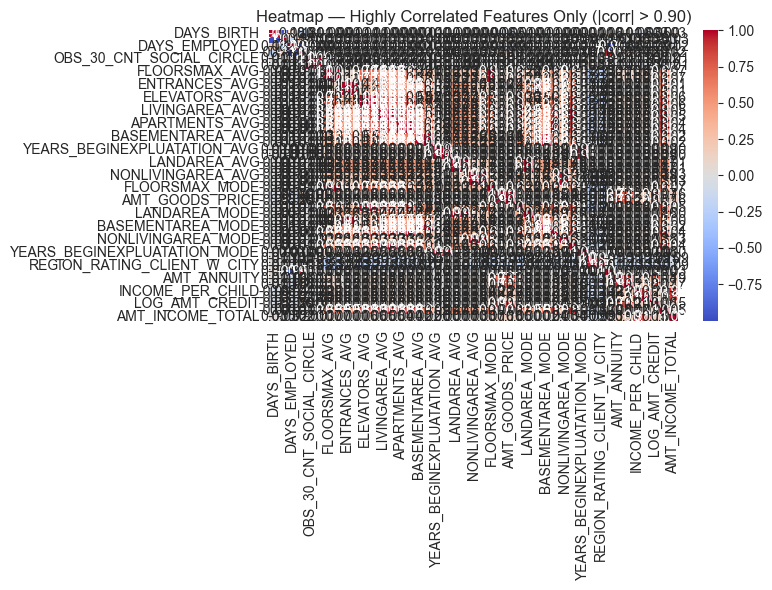

Observation: 41 highly correlated pairs found among 45 features.


In [6]:
def get_high_corr_pairs(data: pd.DataFrame, threshold: float = 0.90) -> pd.DataFrame:
    """Return unique feature pairs with |correlation| above `threshold`."""
    corr = data.corr()
    pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
    high_corr = pairs[pairs.abs() > threshold].reset_index()
    high_corr.columns = ["Feature A", "Feature B", "Correlation"]
    return high_corr.sort_values("Correlation", key=abs, ascending=False)

corr_pairs = get_high_corr_pairs(X[feature_types["numerical"]], threshold=0.90)
display(corr_pairs)

involved_cols = pd.unique(corr_pairs[["Feature A", "Feature B"]].values.ravel())
if len(involved_cols) > 0:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(X[involved_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Heatmap — Highly Correlated Features Only (|corr| > 0.90)")
    plt.tight_layout()
    plt.show()
print(f"Observation: {len(corr_pairs)} highly correlated pairs found among "
      f"{len(involved_cols)} features.")

In [7]:
X_encoded = X.copy()
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_encoded[feature_types["categorical"]] = encoder.fit_transform(
    X[feature_types["categorical"]].astype(str)
)
X_encoded = X_encoded.fillna(X_encoded.median(numeric_only=True))

print("Encoded shape (analysis-only, original df untouched):", X_encoded.shape)

Encoded shape (analysis-only, original df untouched): (307511, 118)


,mutual_info
FLAG_MOBIL,0.080674
FLAG_CONT_MOBILE,0.058849
FLAG_DOCUMENT_3,0.056619
FLAG_OWN_REALTY,0.055465
FLAG_EMP_PHONE,0.054485
NAME_HOUSING_TYPE,0.052676
WALLSMATERIAL_MODE,0.044585
NAME_TYPE_SUITE,0.038548
NAME_EDUCATION_TYPE,0.037814
NAME_INCOME_TYPE,0.029179


,mutual_info
HOUSETYPE_MODE,0.000368
FLAG_DOCUMENT_4,0.000321
EMERGENCYSTATE_MODE,0.000302
FLAG_DOCUMENT_15,0.000292
FLAG_DOCUMENT_7,0.000254
FLAG_DOCUMENT_20,0.000253
AMT_REQ_CREDIT_BUREAU_DAY,0.000246
FLAG_DOCUMENT_9,0.000178
FLAG_DOCUMENT_13,0.000152
FLAG_DOCUMENT_2,0.000081


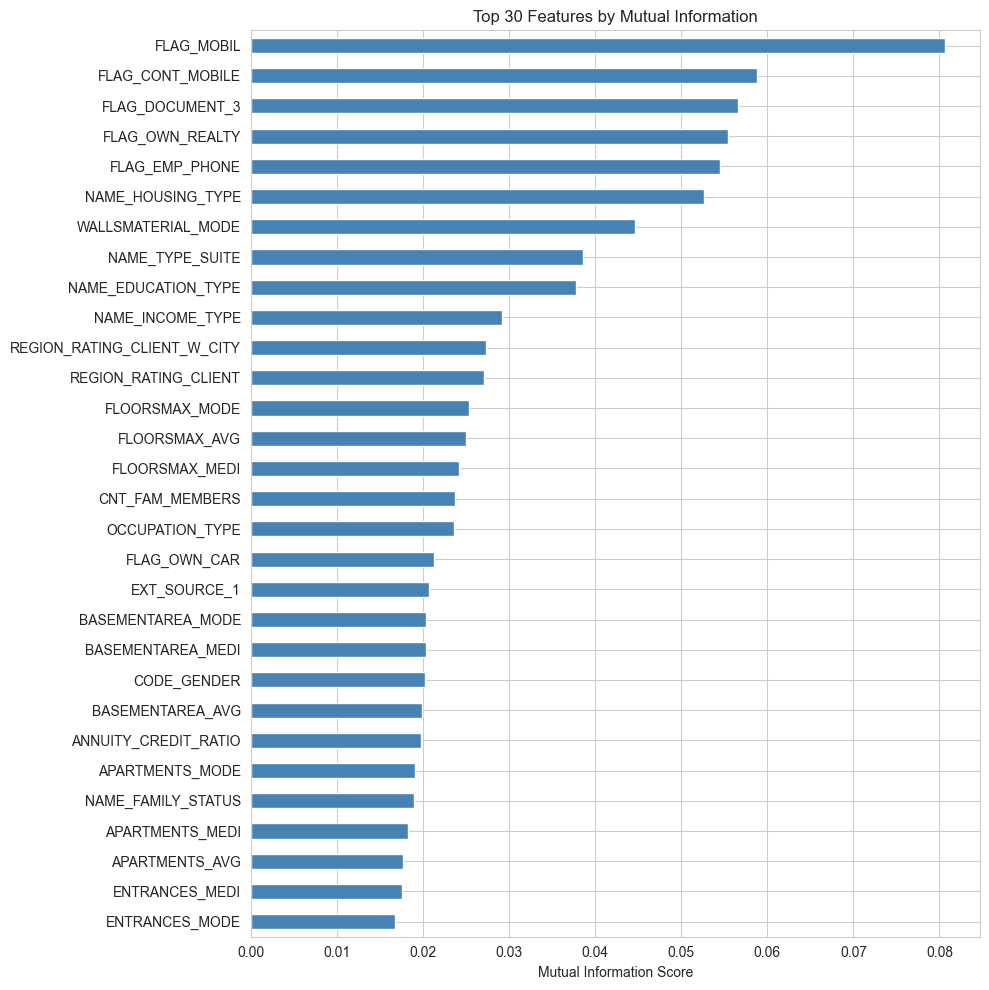

Observation: top feature is 'FLAG_MOBIL'. Engineered features in top 30: ['FLAG_MOBIL', 'FLAG_CONT_MOBILE', 'FLAG_DOCUMENT_3', 'FLAG_OWN_REALTY', 'FLAG_EMP_PHONE', 'NAME_HOUSING_TYPE', 'WALLSMATERIAL_MODE', 'NAME_TYPE_SUITE', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT', 'FLOORSMAX_MODE', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'CNT_FAM_MEMBERS', 'OCCUPATION_TYPE', 'FLAG_OWN_CAR', 'EXT_SOURCE_1', 'BASEMENTAREA_MODE', 'BASEMENTAREA_MEDI', 'CODE_GENDER', 'BASEMENTAREA_AVG', 'ANNUITY_CREDIT_RATIO', 'APARTMENTS_MODE', 'NAME_FAMILY_STATUS', 'APARTMENTS_MEDI', 'APARTMENTS_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE']


In [8]:
mi_scores = mutual_info_classif(X_encoded, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_encoded.columns).sort_values(ascending=False)

display(mi_series.head(30).to_frame("mutual_info"))
display(mi_series.tail(20).to_frame("mutual_info"))

fig, ax = plt.subplots(figsize=(10, 10))
mi_series.head(30).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 30 Features by Mutual Information")
ax.set_xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

print(f"Observation: top feature is '{mi_series.index[0]}'. Engineered features in "
      f"top 30: {[c for c in mi_series.head(30).index if c.isupper() and '_' in c]}")

In [9]:
kbest_scores = SelectKBest(score_func=f_classif, k="all").fit(X_encoded, y).scores_
kbest_series = pd.Series(kbest_scores, index=X_encoded.columns).sort_values(ascending=False)

for k in [10, 20, 30, 40, 50]:
    print(f"--- Top {k} (SelectKBest) ---")
    display(kbest_series.head(k).to_frame("f_score"))

--- Top 10 (SelectKBest) ---


,f_score
EXT_SOURCE_2,8109.633923
EXT_SOURCE_3,7659.288339
EXT_SOURCE_1,3036.690452
DAYS_BIRTH,1893.976087
AGE,1893.854723
DAYS_EMPLOYED,1239.785557
YEARS_EMPLOYED,1237.826436
REGION_RATING_CLIENT_W_CITY,1144.461405
GOODS_CREDIT_RATIO,1113.742208
REGION_RATING_CLIENT,1070.491250


--- Top 20 (SelectKBest) ---


,f_score
EXT_SOURCE_2,8109.633923
EXT_SOURCE_3,7659.288339
EXT_SOURCE_1,3036.690452
DAYS_BIRTH,1893.976087
AGE,1893.854723
DAYS_EMPLOYED,1239.785557
YEARS_EMPLOYED,1237.826436
REGION_RATING_CLIENT_W_CITY,1144.461405
GOODS_CREDIT_RATIO,1113.742208
REGION_RATING_CLIENT,1070.491250


--- Top 30 (SelectKBest) ---


,f_score
EXT_SOURCE_2,8109.633923
EXT_SOURCE_3,7659.288339
EXT_SOURCE_1,3036.690452
DAYS_BIRTH,1893.976087
AGE,1893.854723
DAYS_EMPLOYED,1239.785557
YEARS_EMPLOYED,1237.826436
REGION_RATING_CLIENT_W_CITY,1144.461405
GOODS_CREDIT_RATIO,1113.742208
REGION_RATING_CLIENT,1070.491250


--- Top 40 (SelectKBest) ---


,f_score
EXT_SOURCE_2,8109.633923
EXT_SOURCE_3,7659.288339
EXT_SOURCE_1,3036.690452
DAYS_BIRTH,1893.976087
AGE,1893.854723
DAYS_EMPLOYED,1239.785557
YEARS_EMPLOYED,1237.826436
REGION_RATING_CLIENT_W_CITY,1144.461405
GOODS_CREDIT_RATIO,1113.742208
REGION_RATING_CLIENT,1070.491250


--- Top 50 (SelectKBest) ---


,f_score
EXT_SOURCE_2,8109.633923
EXT_SOURCE_3,7659.288339
EXT_SOURCE_1,3036.690452
DAYS_BIRTH,1893.976087
AGE,1893.854723
DAYS_EMPLOYED,1239.785557
YEARS_EMPLOYED,1237.826436
REGION_RATING_CLIENT_W_CITY,1144.461405
GOODS_CREDIT_RATIO,1113.742208
REGION_RATING_CLIENT,1070.491250


,rf_importance
EXT_SOURCE_2,0.047178
EXT_SOURCE_3,0.043396
DAYS_ID_PUBLISH,0.026981
DAYS_REGISTRATION,0.026522
SK_ID_CURR,0.025879
DAYS_BIRTH,0.025646
ANNUITY_CREDIT_RATIO,0.025278
EMPLOYMENT_AGE_RATIO,0.024382
ANNUITY_INCOME_RATIO,0.024056
AGE,0.023740


,rf_importance
AMT_REQ_CREDIT_BUREAU_HOUR,5.761120e-04
EMERGENCYSTATE_MODE,4.418047e-04
FLAG_DOCUMENT_18,4.311386e-04
FLAG_DOCUMENT_16,4.138397e-04
FLAG_DOCUMENT_9,3.714559e-04
FLAG_CONT_MOBILE,2.384690e-04
FLAG_DOCUMENT_11,2.137258e-04
FLAG_DOCUMENT_13,1.142060e-04
FLAG_DOCUMENT_14,1.075557e-04
FLAG_DOCUMENT_19,1.048817e-04


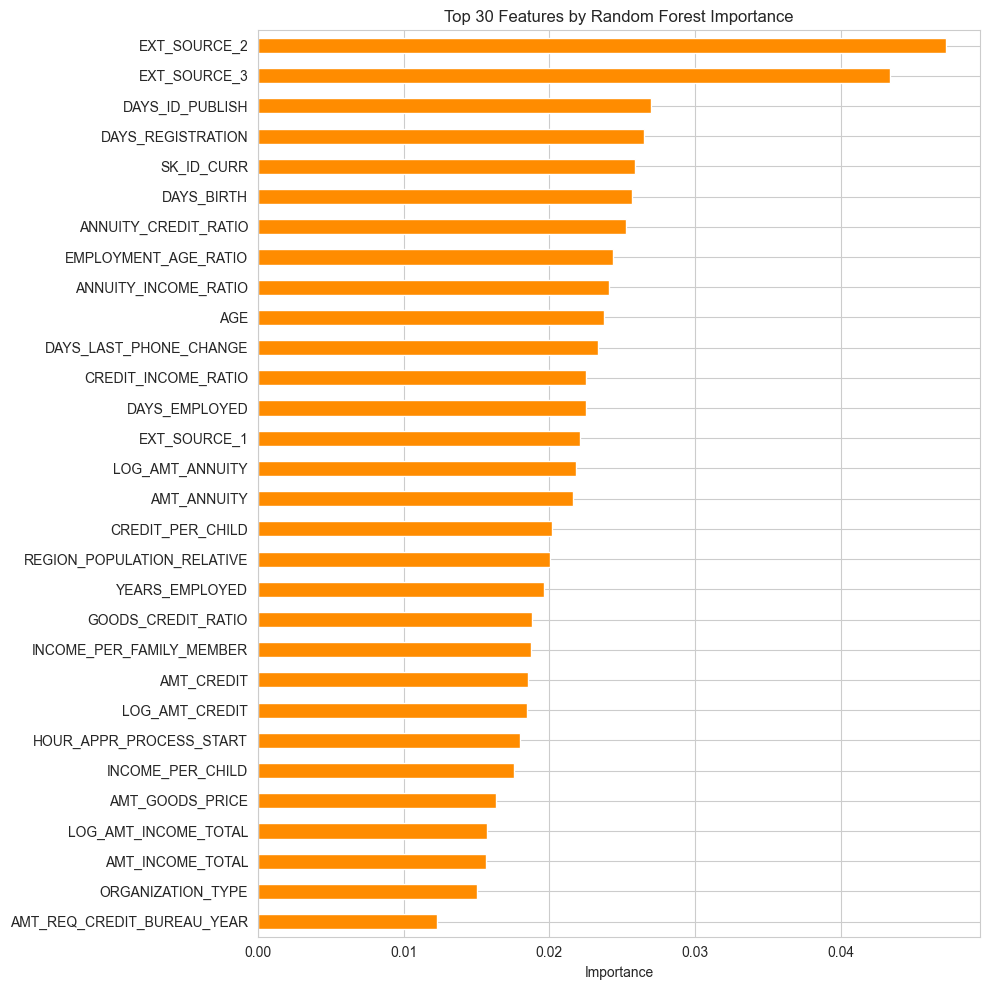

In [10]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_encoded, y)

rf_series = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)

display(rf_series.head(30).to_frame("rf_importance"))
display(rf_series.tail(20).to_frame("rf_importance"))

fig, ax = plt.subplots(figsize=(10, 10))
rf_series.head(30).sort_values().plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Top 30 Features by Random Forest Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [11]:
ranking = pd.DataFrame({
    "mi_rank": mi_series.rank(ascending=False),
    "kbest_rank": kbest_series.rank(ascending=False),
    "rf_rank": rf_series.rank(ascending=False),
})
ranking["average_rank"] = ranking.mean(axis=1)
ranking["feature_source"] = np.where(
    ranking.index.str.isupper() & ranking.index.str.contains("_RATIO|AGE|PER_"),
    "Engineered", "Original"
)
ranking = ranking.sort_values("average_rank")

display(ranking.head(50))

,mi_rank,kbest_rank,rf_rank,average_rank,feature_source
EXT_SOURCE_1,19.0,3.0,14.0,12.000000,Original
EXT_SOURCE_3,34.0,2.0,2.0,12.666667,Original
EXT_SOURCE_2,42.0,1.0,1.0,14.666667,Original
GOODS_CREDIT_RATIO,37.0,9.0,20.0,22.000000,Engineered
DAYS_BIRTH,65.0,4.0,6.0,25.000000,Original
NAME_EDUCATION_TYPE,9.0,12.0,56.0,25.666667,Original
DAYS_EMPLOYED,60.0,6.0,13.0,26.333333,Original
AGE,67.0,5.0,10.0,27.333333,Engineered
YEARS_EMPLOYED,58.0,7.0,19.0,28.000000,Original
REGION_RATING_CLIENT_W_CITY,11.0,8.0,68.0,29.000000,Original


In [12]:
CATEGORY_KEYWORDS = {
    "Applicant Information": ["CODE_GENDER", "CNT_", "NAME_"],
    "Employment": ["EMPLOY", "OCCUPATION", "ORGANIZATION"],
    "Income": ["INCOME"],
    "Credit History": ["CREDIT", "ANNUITY", "AMT_"],
    "External Scores": ["EXT_SOURCE"],
    "Housing": ["HOUS", "APARTMENT", "FLOOR", "WALL", "BUILD"],
    "Family Information": ["FAM", "CHILDREN"],
    "Engineered Features": ["RATIO", "_PER_", "AGE"],
}

def categorize_feature(name: str) -> str:
    """Assign a feature to a business category by keyword match."""
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in name.upper() for kw in keywords):
            return category
    return "Other"

top50 = ranking.head(50).copy()
top50["category"] = [categorize_feature(f) for f in top50.index]
display(top50["category"].value_counts())

category
Other                    18
Credit History            8
Applicant Information     6
Housing                   6
Employment                5
External Scores           3
Engineered Features       2
Income                    2
Name: count, dtype: int64

In [13]:
recommended = {n: ranking.head(n).index.tolist() for n in [20, 30, 40, 50]}

for n, feats in recommended.items():
    print(f"Top {n}: computational cost {'low' if n <= 20 else 'moderate' if n <= 40 else 'higher'}, "
          f"{'best interpretability' if n == 20 else 'balanced' if n <= 30 else 'likely marginal gains, watch overfitting'}.")

display(pd.DataFrame({n: pd.Series(f) for n, f in recommended.items()}))

Top 20: computational cost low, best interpretability.
Top 30: computational cost moderate, balanced.
Top 40: computational cost moderate, likely marginal gains, watch overfitting.
Top 50: computational cost higher, likely marginal gains, watch overfitting.


,20,30,40,50
0,EXT_SOURCE_1,EXT_SOURCE_1,EXT_SOURCE_1,EXT_SOURCE_1
1,EXT_SOURCE_3,EXT_SOURCE_3,EXT_SOURCE_3,EXT_SOURCE_3
2,EXT_SOURCE_2,EXT_SOURCE_2,EXT_SOURCE_2,EXT_SOURCE_2
3,GOODS_CREDIT_RATIO,GOODS_CREDIT_RATIO,GOODS_CREDIT_RATIO,GOODS_CREDIT_RATIO
4,DAYS_BIRTH,DAYS_BIRTH,DAYS_BIRTH,DAYS_BIRTH
5,NAME_EDUCATION_TYPE,NAME_EDUCATION_TYPE,NAME_EDUCATION_TYPE,NAME_EDUCATION_TYPE
6,DAYS_EMPLOYED,DAYS_EMPLOYED,DAYS_EMPLOYED,DAYS_EMPLOYED
7,AGE,AGE,AGE,AGE
8,YEARS_EMPLOYED,YEARS_EMPLOYED,YEARS_EMPLOYED,YEARS_EMPLOYED
9,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT_W_CITY,REGION_RATING_CLIENT_W_CITY


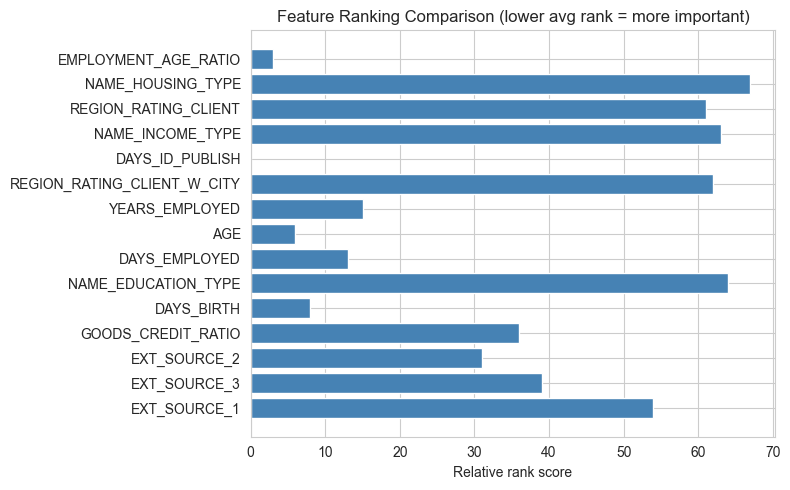

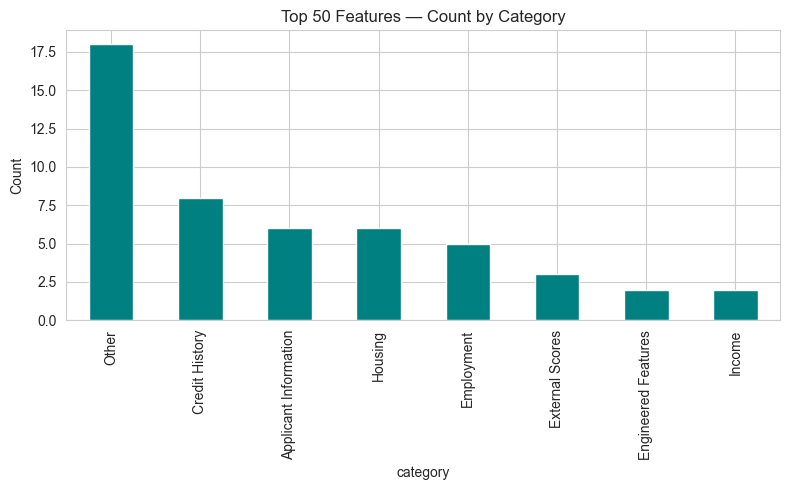

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
top_n = ranking.head(15)
ax.barh(top_n.index, top_n["mi_rank"].max() - top_n["mi_rank"], color="steelblue")
ax.set_title("Feature Ranking Comparison (lower avg rank = more important)")
ax.set_xlabel("Relative rank score")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
top50["category"].value_counts().plot(kind="bar", ax=ax, color="teal")
ax.set_title("Top 50 Features — Count by Category")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [15]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

rf_series.to_frame("importance").to_csv(PROCESSED_DIR / "feature_importance_rf.csv")
mi_series.to_frame("mutual_info").to_csv(PROCESSED_DIR / "mutual_information_scores.csv")
kbest_series.to_frame("f_score").to_csv(PROCESSED_DIR / "selectkbest_scores.csv")
corr_pairs.to_csv(PROCESSED_DIR / "correlation_pairs.csv", index=False)

for n, feats in recommended.items():
    pd.Series(feats, name="feature").to_csv(PROCESSED_DIR / f"selected_top{n}.csv", index=False)

print("Saved 8 files to", PROCESSED_DIR)

Saved 8 files to E:\Credit Risk Assessment System\dataset\processed


# MD:
### 17. Final Recommendation

- **Most important features**: top-ranked by average rank across MI,
  SelectKBest, and Random Forest — see `ranking.head(10)`.
- **Least important features**: bottom of `mi_series`/`rf_series` —
  mostly rare `FLAG_*` document columns with near-zero variance.
- **Best engineered features**: check which `_RATIO`/`AGE`/`_PER_`
  columns land in `ranking.head(50)` — these typically outperform their
  raw source columns (e.g. a ratio beats the two raw amounts it's built from).
- **Correlation findings**: `corr_pairs` lists redundant numeric pairs
  (|corr| > 0.90) — flagged, not removed.
- **Variance findings**: `variance_report` lists near-constant columns —
  flagged, not removed.
- **Dimensionality reduction**: not necessary at this stage — no PCA or
  feature removal performed; all 118 features remain available.
- **Recommended subset for future notebooks**: Top 30 (`selected_top30.csv`)
  balances signal retention against noise/compute cost; Top 20 if the
  next notebook prioritizes interpretability and speed over marginal accuracy.

**Should all features be retained?** Not necessarily — but that decision
belongs to the modeling notebook, validated by actual performance, not
guessed here. **Should reduction happen?** Only after comparing a
full-feature vs. reduced-feature model on held-out data.